# Combing AlexNet and GoogLeNet

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import numpy as np
%matplotlib inline

In [2]:
# 展示高清图
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

In [3]:
print(torch.__version__)

2.5.1+cu121


In [4]:
# 超参数
seed = 1145
batch_size = 256
epochs = 100
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
learning_rate = 0.1
print('Using device:', device)

Using device: cuda


In [5]:
torch.manual_seed(seed)

In [6]:
# 制作数据集

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.Normalize(0.1307, 0.3081)
])

train_dataset = datasets.MNIST(root='./datasets/mnist', 
                               train=True, 
                               download=True, 
                               transform=transform)
test_dataset = datasets.MNIST(root='./datasets/mnist', 
                              train=False, 
                              download=True, 
                              transform=transform)

from torch.utils.data import random_split

# 原始训练集 60000 张，切出 50000 训练、10000 验证
train_size = 50000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
   
)


In [7]:
# 批次加载器
train_loader = DataLoader(dataset=train_subset, 
                          batch_size=batch_size, 
                          shuffle=True)     # 打乱数据
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)
val_loader = DataLoader(dataset=val_subset,
                        batch_size=batch_size,
                        shuffle=False)

In [8]:
# 一个Inception模块
class Inception(nn.Module):
    def __init__(self, in_channels,out1, out2, out3, out4):
        super(Inception, self).__init__()
        # 1x1 卷积
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out1, kernel_size=1),nn.ReLU()
            )

        # 1x1 卷积 -> 3x3 卷积
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out2, kernel_size=1),nn.ReLU(),
            nn.Conv2d(out2, out3, kernel_size=3, padding=1),nn.ReLU(),
            nn.Conv2d(out3, out4, kernel_size=3, padding=1),nn.ReLU()
        )

        # 1x1 卷积 -> 5x5 卷积
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out1, kernel_size=1),nn.ReLU(),
            nn.Conv2d(out1, out2, kernel_size=5, padding=2),nn.ReLU()
        )

        # 3x3 最大池化 -> 1x1 卷积
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),nn.ReLU(),
            nn.Conv2d(in_channels, out4, kernel_size=1),nn.ReLU()
        )

    def forward(self, x):
        branch1_out = self.branch1(x)
        branch2_out = self.branch2(x)
        branch3_out = self.branch3(x)
        branch4_out = self.branch4(x)

        # 将四个分支的输出在通道维度上拼接
        outputs = [branch1_out, branch2_out, branch3_out, branch4_out]
        return torch.cat(outputs, dim=1)

In [9]:
class AGNet(nn.Module):
    def __init__(self):
        super(AGNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            Inception(in_channels=96,out1=32, out2=32, out3=64, out4=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            Inception(in_channels=256,out1=64, out2=64, out3=128, out4=128),
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3,stride=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.net(x)
        return x

In [72]:
# 查看网络结构
X = torch.rand(size=(1, 1, 224, 224))     # 随机生成测试图
for layer in AGNet().net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 96, 54, 54])
ReLU output shape: 	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape: 	 torch.Size([1, 96, 26, 26])
Inception output shape: 	 torch.Size([1, 192, 26, 26])
ReLU output shape: 	 torch.Size([1, 192, 26, 26])
MaxPool2d output shape: 	 torch.Size([1, 192, 12, 12])
Conv2d output shape: 	 torch.Size([1, 256, 12, 12])
ReLU output shape: 	 torch.Size([1, 256, 12, 12])
Inception output shape: 	 torch.Size([1, 384, 12, 12])
ReLU output shape: 	 torch.Size([1, 384, 12, 12])
Conv2d output shape: 	 torch.Size([1, 256, 5, 5])
ReLU output shape: 	 torch.Size([1, 256, 5, 5])
MaxPool2d output shape: 	 torch.Size([1, 256, 2, 2])
Flatten output shape: 	 torch.Size([1, 1024])
Linear output shape: 	 torch.Size([1, 512])
ReLU output shape: 	 torch.Size([1, 512])
Dropout output shape: 	 torch.Size([1, 512])
Linear output shape: 	 torch.Size([1, 256])
ReLU output shape: 	 torch.Size([1, 256])
Dropout output shape: 	 torch.Size([1, 256])
Linear output shape:

In [73]:
model = AGNet().to(device)

In [74]:
# 损失函数
loss_fn = nn.CrossEntropyLoss()

In [75]:
# 优化算法
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [76]:
# 训练网络
losses = []
epoch_losses = []
losses_val = []
best_epoch = -1
best_acc = 0
min_losses_val = float('inf')
accs = []
patience = 5
bad_epochs = 0
for epoch in range(epochs):
    start = time.time()
    model.train()
    epoch_loss = 0
    for (x,y) in train_loader:
        x,y = x.to(device),y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        epoch_loss += loss.item()
    end = time.time()
    # 测试网络
    correct = 0
    total = 0
    model.eval()
    loss_val = 0
    with torch.no_grad():
        for data in val_loader:
            images, labels = data
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            loss_val += loss_fn(outputs, labels)
            _, predicted = torch.max(outputs, 1)       # 索引/预测结果
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    avg_loss_val = loss_val.item() / len(val_loader)
    losses_val.append(avg_loss_val)
    epoch_losses.append(epoch_loss/len(train_loader))
    accs.append(acc)
    print('Epoch: %d, Loss: %.4f, Loss Val: %.4f, Accuracy: %.4f, Time: %.2f' % (epoch, epoch_losses[-1], avg_loss_val, acc, end - start))
    # 准确率
    # if acc > best_acc:
    #     bad_epochs = 0
    #     best_acc = acc
    #     best_epoch = epoch
    #     torch.save(model.state_dict(), "models/GoogLeNet_best_model.pth")
    # else:
    #     bad_epochs += 1
    #     if bad_epochs >= patience:
    #         print(f"Early stopping at epoch {epoch}")
    #         break
    # 验证损失
    if avg_loss_val < min_losses_val:
        min_losses_val = avg_loss_val
        best_epoch = epoch
        torch.save(model.state_dict(), "models/AGNet_best_model.pth")
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch: 0, Loss: 2.2997, Loss Val: 2.2938, Accuracy: 0.1159, Time: 57.10
Epoch: 1, Loss: 2.2180, Loss Val: 1.8619, Accuracy: 0.4352, Time: 59.68
Epoch: 2, Loss: 0.9094, Loss Val: 0.4971, Accuracy: 0.8372, Time: 58.44
Epoch: 3, Loss: 0.2213, Loss Val: 0.2675, Accuracy: 0.9207, Time: 82.00
Epoch: 4, Loss: 0.1435, Loss Val: 0.0762, Accuracy: 0.9771, Time: 91.08
Epoch: 5, Loss: 0.0837, Loss Val: 0.0626, Accuracy: 0.9811, Time: 77.27
Epoch: 6, Loss: 0.0679, Loss Val: 0.1986, Accuracy: 0.9387, Time: 75.86
Epoch: 7, Loss: 0.0600, Loss Val: 0.0478, Accuracy: 0.9841, Time: 106.13
Epoch: 8, Loss: 0.0477, Loss Val: 0.0509, Accuracy: 0.9848, Time: 97.09
Epoch: 9, Loss: 0.0397, Loss Val: 0.0386, Accuracy: 0.9878, Time: 95.31
Epoch: 10, Loss: 0.0357, Loss Val: 0.0475, Accuracy: 0.9856, Time: 84.87
Epoch: 11, Loss: 0.0327, Loss Val: 0.0361, Accuracy: 0.9886, Time: 89.10
Epoch: 12, Loss: 0.0290, Loss Val: 0.0357, Accuracy: 0.9888, Time: 90.34
Epoch: 13, Loss: 0.0248, Loss Val: 0.0344, Accuracy: 0.9887,

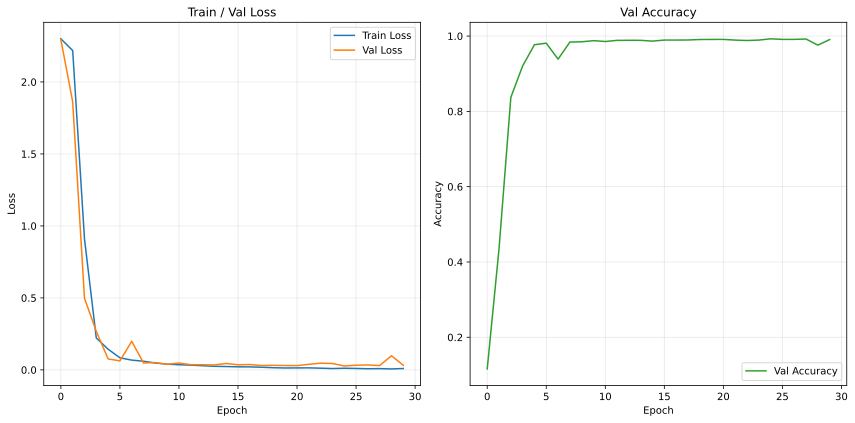

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ep = range(len(epoch_losses))

# 左图：训练损失 + 验证损失 放同一张图
ax[0].plot(ep, epoch_losses, label='Train Loss')
ax[0].plot(ep, losses_val,  label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Train / Val Loss')
ax[0].legend()
ax[0].grid(alpha=0.3)

# 右图：验证准确率
ax[1].plot(range(len(accs)), accs, label='Val Accuracy', color='tab:green')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Val Accuracy')
ax[1].legend()
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [78]:
model.load_state_dict(torch.load("models/AGNet_best_model.pth"))
# 测试网络
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images,labels = images.to(device),labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)       # 索引/预测结果
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network: %.4f %%' % (
    100 * correct / total))

C:\Users\HONOR\AppData\Local\Temp\ipykernel_21128\2477242731.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/AGNet_best_model.pt

Accuracy of the network: 99.2700 %


In [10]:
# 每个数字取 2 张，共 20 张；始终训练同一批
indices = torch.cat([
    torch.where(train_dataset.targets == digit)[0][:2]
    for digit in range(10)
])
tiny_loader = DataLoader(
    torch.utils.data.Subset(train_dataset, indices.tolist()),
    batch_size=20
)
x, y = next(iter(tiny_loader))
x, y = x.to(device), y.to(device)

model = AGNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

for step in range(501):
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        acc = (logits.argmax(1) == y).float().mean().item()
        print(step, f"loss={loss.item():.4f}", f"accuracy={acc:.0%}")

0 loss=2.3056 accuracy=10%
100 loss=0.2969 accuracy=95%
200 loss=0.2099 accuracy=95%
300 loss=0.0024 accuracy=100%
400 loss=0.0009 accuracy=100%
500 loss=0.0000 accuracy=100%
